This Deep Learning project uses transfer learning with InceptionResNetV2 to perform multiclass image classification by identifying 120 different dog breeds from images

In [25]:
# 1. Image Classification
# Image classification is a supervised learning task where images are assigned predefined labels.
# The model learns visual patterns such as edges, shapes, and textures to identify objects.

# 2. Multiclass Classification
# Multiclass classification involves more than two classes.
# In this project, the model classifies images into 120 different dog breeds, making it a multiclass problem.

# 3. Transfer Learning
# Transfer learning uses a pre-trained model to solve a new but related task.
# Instead of training from scratch, we reuse learned features (weights) to save time and improve accuracy.
# Especially useful when the dataset is limited.

# 4. Why Transfer Learning is Used
# Pre-trained models already understand low-level features like edges and textures.
# These features are common across images, making them transferable.
# Reduces training time, computational cost, and overfitting.

# 5. Pre-trained Model
# A pre-trained model is trained on a large-scale dataset (e.g., ImageNet).
# It contains learned weights and biases that capture generic image features.
# Examples include VGG, ResNet, Inception, and InceptionResNetV2.

# 6. InceptionResNetV2
# InceptionResNetV2 is a deep CNN with 164 layers.
# Combines Inception modules (multi-scale feature extraction) with ResNet skip connections (faster convergence).
# Trained on ImageNet (1,000+ classes).
# Requires image input size of 299 × 299.
# Chosen for its high accuracy and stability.

# 7. Fine-Tuning
# Fine-tuning means modifying and retraining the top layers of the pre-trained model.
# The final classification layer is replaced with a 120-class output layer.
# Allows the model to adapt specifically to dog breed classification.

# 8. Dataset
# Total classes: 120 dog breeds
# Training set: 10,222 images
# Test set: 10,357 images
# labels.csv: maps image IDs to breed names
# sample_submission.csv: shows required output format

# 9. Feature Extraction
# The CNN automatically extracts features like edges → shapes → complex patterns.
# Earlier layers learn general features, later layers learn task-specific features.

# 10. GPU Usage
# GPUs significantly speed up training deep neural networks.
# Parallel processing helps handle large images and complex architectures efficiently.


In [26]:
# 1. Import Libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

# deep learning libraries
import tensorflow as tf
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image_dataset_from_directory  # optional alternative

from tensorflow.keras import applications
from keras.models import Sequential, load_model
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten, Dense, Dropout
from keras.preprocessing import image

import cv2

import warnings
warnings.filterwarnings('ignore')


In [27]:
# 1. NumPy
# Used for numerical computations and handling arrays.
# Helps in image preprocessing and mathematical operations on tensors.

# 2. Pandas
# Used for data handling and analysis.
# Helps load and manage labels.csv and sample_submission.csv.

# 3. Seaborn
# A data visualization library built on top of Matplotlib.
# Used to create confusion matrix heatmaps for model evaluation.

# 4. Matplotlib
# Used for plotting graphs such as:
# Training vs validation accuracy
# Training vs validation loss

# 5. Scikit-learn Metrics
# from sklearn.metrics import classification_report, confusion_matrix
# classification_report: Provides precision, recall, F1-score, and accuracy.
# confusion_matrix: Shows class-wise prediction performance.

# Deep Learning Libraries
# 6. TensorFlow
# The core deep learning framework.
# Handles model training, backpropagation, and GPU acceleration.

# 7. Keras
# High-level API built on TensorFlow.
# Simplifies building, training, and evaluating neural networks.

# 8. ImageDataGenerator
# from keras.preprocessing.image import ImageDataGenerator
# Used for image preprocessing and data augmentation.
# Applies transformations like rotation, zoom, flip, and rescaling.
# Helps reduce overfitting.

# 9. Pre-trained Models (Applications)
# from tensorflow.keras import applications
# Provides access to pre-trained models like InceptionResNetV2.
# Enables transfer learning by reusing learned weights.

# 10. Model Handling
# from keras.models import Sequential, load_model
# Sequential: Used to build the model layer by layer.
# load_model: Loads a saved trained model for evaluation or prediction.

# 11. Neural Network Layers
# from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten, Dense, Dropout
# Conv2D: Extracts spatial features from images.
# MaxPooling2D: Reduces spatial dimensions and computation.
# GlobalAveragePooling2D: Reduces overfitting and model size.
# Flatten: Converts feature maps to 1D vector.
# Dense: Fully connected layers for classification.
# Dropout: Prevents overfitting by randomly dropping neurons.

# 12. Image Preprocessing
# from keras.preprocessing import image
# Used to load and preprocess single images for prediction.

# 13. OpenCV
# import cv2
# Used for image reading and resizing.
# Efficient for handling image transformations.

# 14. Warnings
# import warnings
# warnings.filterwarnings('ignore')
# Suppresses unnecessary warnings.
# Helps keep the output clean and readable.


In [28]:
# 2.Load dataset and image folders

# datasets
labels = pd.read_csv("labels.csv")
sample = pd.read_csv('sample_submission.csv')

# folders paths
train_path = "train"
test_path = "test"


In [29]:
# 3. Displaying the first five records of labels dataset to see its attributes.
labels.head()

# 4: Adding .jpg Extension to Each ID
# Append .jpg to every image ID in the dataset so it matches the actual filenames in the folder, enabling the model to retrieve and load images correctly.
def to_jpg(id):
    return id+".jpg"


labels['id'] = labels['id'].apply(to_jpg)
sample['id'] = sample['id'].apply(to_jpg)


,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [30]:
# 5. Augmenting Data: Data augmentation increases dataset diversity by applying transformations like scaling, rotation, brightness changes, and flipping using ImageDataGenerator, helping the model generalize better; key parameters include rescale, horizontal_flip, and validation_split.
# We use ImageDataGenerator to normalize and augment images, then split the dataset into training and validation sets using flow_from_dataframe for efficient batch loading
# Data agumentation and pre-processing using tensorflow
# 5a. ImageDataGenerator performs real-time image preprocessing and augmentation.
# rescale=1./255: Normalizes pixel values from 0–255 to 0–1, improving training stability.
# horizontal_flip=True: Randomly flips images horizontally to improve generalization.
# validation_split=0.2: Splits the data into 80% training and 20% validation.
gen = ImageDataGenerator( # image helper
                  rescale=1./255.,# makes the picture colors smaller numbers so the computer can understand them.
                  horizontal_flip = True,# flip like a mirror
                  validation_split=0.2 # training: 80% data, validation: 20% data
                 )
# 5b. Training Data Generator
train_generator = gen.flow_from_dataframe( # Giving Pictures to Learn From (Training)
    labels, # A list that tells which picture shows which dog
    directory = train_path, # The folder where the dog pictures live
    x_col = 'id', #The picture name.
    y_col = 'breed', #The dog’s name (label).
    subset="training", # Uses 80% of the data for training.These pictures are for learning.
    color_mode="rgb",
    target_size = (331,331), # image height , image width #All pictures are resized to the same size.
    class_mode="categorical",# Converts labels to one-hot encoded vectors for multiclass classification.Dog names are turned into numbers the computer understands.
    batch_size=32, #Loads images in batches to optimize memory.The computer looks at 32 pictures at a time.
    shuffle=True, # Prevents learning order bias.Pictures are mixed up so learning is better.
    seed=42, # Ensures reproducibility.
)

# 5c. Validation Data Generator
# Validation data is not augmented, only rescaled. Helps monitor model performance and overfitting.
validation_generator = gen.flow_from_dataframe( #Checking What It Learned (Validation)
    labels, # dataframe
    directory = train_path, # images data path / folder in which images are there
    x_col = 'id',
    y_col = 'breed',
    subset="validation", # Uses the remaining 20% of the data for validation.
    color_mode="rgb",
    target_size = (331,331), # image height , image width
    class_mode="categorical",
    batch_size=32,
    shuffle=True,
    seed=42,
)


Found 8178 validated image filenames belonging to 120 classes.
Found 2044 validated image filenames belonging to 120 classes.


In [31]:
# 6. Inspecting a Batch of Training Data
x,y = next(train_generator) # takes one small group of pictures from the box.
x.shape # input shape of one record is (331,331,3) , 32: is the batch size
# x contains the pictures.Each picture has:331 pixels height, 331 pixels width, 3 colors (Red, Green, Blue)
# y contains the answers (dog breed names in number form).It tells the computer which dog is in each picture.


(32, 331, 331, 3)

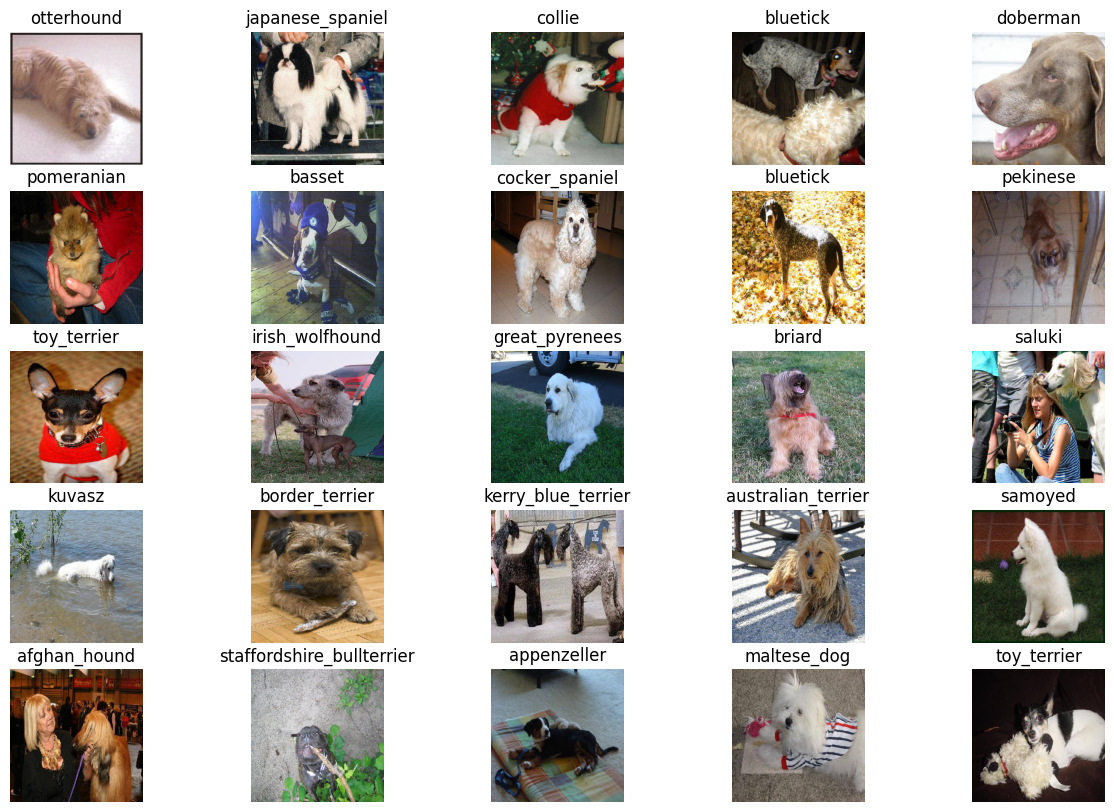

In [32]:
# 7. Plotting images from the train dataset
a = train_generator.class_indices
class_names = list(a.keys())  # storing class/breed names in a list . Get Dog Names in a  list  like: “golden_retriever”, “beagle”, “pug”, …”

def plot_images(img, labels): # This function helps us show pictures on the screen.
    plt.figure(figsize=[15, 10]) # Makes a big board to show many pictures nicely.
    for i in range(25): # show 25 dog pictures (5 rows × 5 columns).
        plt.subplot(5, 5, i+1) # Place Each Picture
        plt.imshow(img[i])
        plt.title(class_names[np.argmax(labels[i])]) # Show the Dog’s Name on top of the picture
        plt.axis('off')

plot_images(x,y)


In [33]:
# 8. Building the Model
# 8a. Use a Super-Smart Brain
# load the InceptionResNetV2 architecture with imagenet weights as base
base_model = tf.keras.applications.InceptionResNetV2( # we borrow a smart brain.
                     include_top=False, # We remove its old “answer part” so we can teach it new dog breeds
                     weights='imagenet',
                     input_shape=(331,331,3)# Each picture is 331 × 331 with 3 colors
                     )

# 8b. Freeze the Smart Brain
base_model.trainable = False # We don’t want to change what it already knows.We lock the brain so it doesn’t forget what it already knows.It only helps extract features like shapes, ears, eyes, and fur.

# 8c. Give the Model a Picture Shape
input_tensor = tf.keras.Input(shape=(331,331,3)) # Tells the computer what size pictures it will see.
output_tensor = base_model(input_tensor) # Sends the picture into the smart brain.

# 8d. Build the Full Model
# We use a smart pre-trained brain to look at dog pictures, add our own thinking layers, and teach it to choose the correct dog breed.
model = tf.keras.Sequential([ # We stack layers like building blocks.
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(), # Clean and Shrink the Information. Shrinks big picture info into something smaller and easier.
        tf.keras.layers.BatchNormalization(), # Helps the computer learn faster and better.
        tf.keras.layers.Dense(512, activation='relu'),# Learning Layers.These layers help the computer think and decide.relu helps it learn important things only.
        tf.keras.layers.Dense(256, activation='relu'), # These layers help the computer think and decide.
        tf.keras.layers.Dropout(0.5), # Prevent Over-Learning. Randomly hides some neurons so the model doesn’t memorize pictures.Helps it guess better on new images
        tf.keras.layers.Dense(128, activation='relu'), # These layers help the computer think and decide.
        tf.keras.layers.Dense(120, activation='softmax') # Final Answer Layer. The model chooses 1 out of 120 dog breeds. softmax gives probability scores for each breed.
    ])
# BatchNormalization
# Normalizes data within each mini-batch.
# Speeds up training and allows higher learning rates.
# Keeps outputs with mean ≈ 0 and standard deviation ≈ 1.

# GlobalAveragePooling2D
# Averages each feature map across its entire height and width.
# Reduces image dimensions and number of parameters.
# Converts feature maps into a 1D vector (one value per channel).

# Dense Layers
# Fully connected layers used for final decision-making.
# Learn relationships between extracted features.
# Commonly placed after convolution layers.

# Dropout Layer
# Randomly removes neurons during training.
# Prevents overfitting.
# Dropout value 0.5 means 50% neurons are dropped.

# BatchNormalization
# Helps keep numbers neat and tidy.
# Makes learning faster.
# Stops numbers from getting too big or too small.

# GlobalAveragePooling2D
# Shrinks a big picture into small, useful information.
# Takes the average of each picture part.
# Makes the computer’s job easier.

# Dense Layers
# These are the thinking layers.
# Help the computer decide what it is seeing.
# Connected to everything before them.

# Dropout Layer
# Makes the computer not cheat by memorizing.
# Randomly hides some neurons while learning.
# Helps it get better at new pictures.

# These layers help the computer learn faster, think better, and not memorize too much.

# Softmax
# Imagine you have 120 dog treats, and the computer has to choose which one is the yummiest.
# Softmax gives a probability to each treat (or dog breed).
# The highest probability is the computer’s final guess.
# Simple: “It helps the computer pick the most likely dog breed.”

# CNN (Convolutional Neural Network)
# A CNN is like a super-smart detective for pictures.
# It looks for edges, shapes, colors, and patterns in the image.
# First layers see simple things like lines and colors.
# Later layers see complex things like a dog’s face or ears.
# Simple: “CNN helps the computer see and understand images.”

# Overfitting
# Overfitting is when the computer memorizes pictures instead of learning.
# Example: If it remembers only the exact photo of your dog, it will fail on new photos.
# Dropout, augmentation, and validation data stop overfitting.
# Simple: “Overfitting = being too smart for the training set but bad at new pictures.”

# Softmax helps pick the best answer, CNN is the computer’s eye to see pictures, and overfitting is when it memorizes too much and forgets how to generalize.


In [34]:
# 9. Compiling the Model
model.compile(optimizer='Adam',loss='categorical_crossentropy',metrics=['accuracy'])
# categorical cross entropy is taken since its used as a loss function for  multi-class classification problems where there are two or more output labels. using Adam optimizer for better performance. other optimizers such as sgd can also be used depending upon the model

# Optimizer = Adam. Think of it as a helper that tells the computer how to learn faster. Guides the model to improve guesses step by step.
# Loss = Categorical Crossentropy.This is like a scorekeeper. It checks how wrong the computer’s guesses are. Used when there are many classes, like 120 dog breeds
# Metrics = Accuracy. Tells us how many guesses were correct during training.
# We give the model a learning plan, a way to check mistakes, and a way to score itself


In [35]:
# 10. Model Summary
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_resnet_v2             │ (None, 9, 9, 1536)     │    54,336,736 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_407         │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 120)            │        15,480 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,309,528 (210.99 MB)

 Trainable params: 969,720 (3.70 MB)

 Non-trainable params: 54,339,808 (207.29 MB)

In [36]:
# Model Summary 
# 1. InceptionResNetV2 (Big Brain)
# This is the smart brain we borrowed.
# It looks at pictures and finds important details like eyes, ears, and shapes.
# Output: 9 × 9 × 1536 small feature maps.
# Most of it is locked (not trainable) so it doesn’t forget what it knows.

# 2. Global Average Pooling
# Shrinks the big picture information into 1536 useful numbers.
# Makes the model faster and lighter.
# No learning happens here.

# 3. Batch Normalization
# Keeps numbers clean and balanced.
# Helps the model learn faster and better.

# 4. Dense Layer (512)
# First thinking layer.
# Learns patterns from the picture features.

# 5. Dense Layer (256)
# Second thinking layer.
# Makes the decision more clear and accurate.

# 6. Dropout
# Randomly hides some neurons.
# Stops the model from memorizing pictures.

# 7. Dense Layer (128)
# Final thinking before answering.
# Prepares information for the last decision.

# 8. Output Layer (120)
# Picks one dog breed out of 120.
# Uses softmax to choose the best answer.

# Parameters
# Total params: All the brain’s numbers.
# Trainable params: Numbers the model is allowed to learn.
# Non-trainable params: Numbers that are locked (from the smart brain).
# This means:
# Big brain is already trained.
# Only the new layers learn dog breeds.

# The model uses a big smart brain to look at pictures, then smaller thinking layers to decide which dog it is.


In [37]:
# Training the Model (model.fit)
# What Does Training Mean?
# Training is when the computer looks at dog pictures again and again.
# Each time, it:
# Guesses the dog breed
# Checks how wrong it was
# Tries to do better next time
# Just like practicing for an exam 

# Example Training Code (Typical)
# history = model.fit(
#     train_generator,
#     validation_data=validation_generator,
#     epochs=10
# )

#  What?
# train_generator
# Gives the computer pictures to learn from.

# validation_generator
# Gives test pictures to check how smart it is.
# These pictures are not used for learning, only checking.

# epochs=10
# Means the computer sees all training pictures 10 times.
# More epochs = more practice (but too many = tired brain )
#  What Happens During Training?
# The computer prints:
# Accurate → how many answers were right
# It → how wrong the answers were
# IN
# Accuracy ⬆️ higher
# Loss ⬇️ lower

# Training is when the computer practices with dog pictures many times and slowly learns to guess better.


In [38]:
# Training vs Validation 
# What is Training Accuracy?
# This shows how good the computer is on pictures it practices with.
# If this number goes up ⬆️, the computer is learning.
# What is Validation Accuracy?
# This shows how good the computer is on new pictures it has never practiced on.
# This tells us if the computer is actually smart, not just memorizing.
# What is Loss?
# Loss means how wrong the computer is.
# Big loss ❌ = very wrong
# Small loss ✅ = doing well
# We want loss to go down ⬇️.

# Understanding the Graphs
# Accuracy Graph
# Training accuracy line: how well it learns from practice pictures.
# In:
# Best case: both lines go up together.
# Loss Graph
# Training loss: mistakes on practice pictures.
# Choose: mistakes on new pictures.
# Best case: both lines go down together.
# What is a Problem?
# If training accuracy ⬆️ but validation accuracy ⬇️
# The computer is memorizing (this is called overfitting).

# Training shows how well the computer practices, validation shows how smart it really is, and loss shows how wrong it is.


In [39]:
# What is Early Stopping?
# Imagine you are studying for a test.
# After some time, studying more doesn’t help and just makes you tired.
# Early stopping tells the computer:
# "Stop learning now, you’re not getting better.”
# Why Do We Use It?
# Stops the computer from memorizing pictures.
# Saves time and energy.
# Keeps the best version of the model.
# What Does It Watch?
# It watches the validation score (new pictures).

# Fine-Tuning
# What Is Fine-Tuning?
# First, we lock the big brain so it doesn’t change.
# Later, we unlock a small part of it so it can learn dog-specific it.
# Why Do We Do This?
# The big brain knows general things (edges, shapes).
# Fine-tuning helps it learn special dog features (ears, fur, face).
# How It Works (Simple Steps)
# Train only the new layers first.
# Unlock the top layers of the big brain.
# Train again with small steps (low learning rate).

# Fine-tuning lets the big brain learn a little more, without forgetting what it already knows.

# How the Model Predicts Dog Breeds
# Step 1: Look at the Picture
# The model gets one dog picture.
# The picture is resized and cleaned.
# Step 2: See Important Things
# The CNN finds:
# Shapes
# Eyes, ears, fur
# Patterns
# Dense layers mix all the information.
# The model decides which breed fits best.

# Step 4: Pick the Best Answer (Softmax)
# Softmax gives a score to each dog breed.
# The breed with the highest score wins.
# The model looks at the dog picture, finds important parts, thinks carefully, and picks the breed it believes is best.
# Fine-tuning allows the upper layers of the pre-trained model to adapt to dog-specific features.

# Prediction:The model extracts features using CNN layers and predicts the dog breed using a softmax classifier.


In [40]:
# Multiclass Image Classification Using Transfer Learning
# -------------------------------------------------------
# 1. What Is the Goal?
# Teach the computer to look at a dog picture and tell which breed it is.
# There are 120 different dog breeds.

# 2. Getting the Pictures Ready
# All pictures are resized to the same size.
# Colors are made easy numbers for the computer.
# Pictures are sometimes flipped to help learning.

# 3. Using a Smart Brain (Transfer Learning)
# We use a pre-trained model called InceptionResNetV2.
# It already knows how to see shapes and patterns.
# We lock this brain so it doesn’t forget.

# 4. Adding Our Own Thinking Layers
# We add layers that help the model think about dog breeds.
# Dropout is used so the model doesn’t memorize pictures.

# 5. Teaching the Model
# The model learns by:
# Guessing the dog breed
# Checking how wrong it is
# Trying again and again
# We keep some pictures to test it while learning.

# 6. Checking the Model
# Validation data checks if the model is really smart.
# If it starts memorizing, we stop training early.

# 7. Final Answer
# The last layer (Softmax) picks one breed out of 120.
# The breed with the highest score is the answer.

# We teach a computer to recognize dog breeds by showing it many pictures and helping it learn without memorizing.This project uses transfer learning with InceptionResNetV2 to perform multiclass dog breed classification using data augmentation, fine-tuning, and softmax-based prediction


In [41]:
# 11. CallBack
# A callback is like a teacher watching the computer learn.It can step in while the computer is learning and help it.
early = tf.keras.callbacks.EarlyStopping( patience=10,
                                          min_delta=0.001,
                                          restore_best_weights=True)
# early stopping call back to stop the training when there is no improvement in validation loss for 10 consecutive epochs. It helps to prevent overfitting and saves training time by restoring the best model weights.
# EarlyStopping:➜ Tells the computer when to stop learning.
# patience = 10:➜ Waits for 10 tries to see improvement before stopping.
# min_delta = 0.001: ➜ Only counts improvement if it gets a little better.
# restore_best_weights = True: ➜ Keeps the best version of the model, not the last one.
# Early stopping watches the model while it learns and stops it when it’s not getting better, keeping the best result.
# Early stopping is used to prevent overfitting by stopping training when validation performance stops improving


In [42]:
# ModelCheckpoint (Saving the Best Model)
# What Is ModelCheckpoint?
# Imagine taking a photo of your best score in a game
# ModelCheckpoint saves the model when it performs best.

#  Why Do We Use It?
# Keeps the best version of the model.
# If training goes wrong later, we can go back to the best one.
# ModelCheckpoint saves the model when it is doing its best.

#  Learning Rate (How Fast the Model Learns)
#  What Is Learning Rate?
# Learning rate is how big a step the computer takes when learning.
# Big step  → learns fast but may fall.
# Small step  → learns slowly but safely.
#  Why It Matters
# Too big → bad learning.
# Too small → very slow learning.
# We choose a balanced value.
# Learning rate decides how fast the computer learns.

#  Final Prediction Code (Guessing Dog Breed)
#  In
# The model gets one dog picture.
# It cleans and resizes the picture.
# It guesses the dog breed.

# Simple Prediction Code
# img = image.load_img("dog.jpg", target_size=(331,331))
# img = image.img_to_array(img)
# img = img / 255.0
# img = np.expand_dims(img, axis=0)

# prediction = model.predict(img)
# predicted_breed = class_names[np.argmax(prediction)]

# print(predicted_breed)

# What This Code Does 
# Loads a dog picture 
# Makes it the right size 
# Lets the model guess 
# At
# Final Tiny Summary
# ModelCheckpoint saves the best model, learning rate controls how fast it learns, and prediction code helps the model tell which dog it sees.


In [43]:
# Evaluation Metrics
# What Are Evaluation Metrics?
# Evaluation metrics are like a report card  for the model.
# They tell us how well the computer is doing.
# They check right answers and mistakes.

# 1.Accuracy
# Accuracy means: How many answers were correct?
# Example:
# 100 pictures
# 80 correct guesses
# Accuracy = 80%
# Accuracy tells how often the computer is right.

# 2.Precision
# Precision means: How careful the computer is when it says something.
# Example:
# 7 times it is correct
# Precision = 7/10
# Precision checks if the computer’s guesses are trustworthy.

# 3.Recall
# Recall means: Did the computer find all the correct ones?
# AND
# There are 10 Beagles
# Computer found only 6
# Recall = 6/10
# Recall checks if the computer misses something.

# 4. F1-Score
# F1-Score is a balance between precision and recall.
# Used when both are important.
# F1-score tells how smart and careful the computer is together.

# 5. Confusion Matrix
# A confusion matrix is a table that shows:
# Right guesses ✅
# Wrong guesses ❌
# Helps see where the model is confused.
# Confusion matrix shows what the computer got right and wrong.

# 6. Loss
# Loss means how wrong the model is.
# Smaller loss = better model.
# Loss tells how big the mistakes are.

# Evaluation metrics like accuracy, precision, recall, F1-score, and confusion matrix are used to measure how well the model performs.
# Evaluation metrics tell us how good the computer is at guessing.

#  Precision vs Recall (Easy Comparison)
# Precision
# Precision = How careful the model is
# Question: “When the model says this breed, is it correct?”
# Example:
# Model says “Pug” 10 times
# Correct 7 times
# Precision = 7/10
# Precision checks if the guesses are correct.

# Recall
# Recall = How much the model finds
# Question: “Did the model find all the Pugs?”
# There are 10 Pugs
# Model found 6
# Recall = 6/10
# “Recall checks if the model missed something.”

# Precision = correct guesses
# Recall = found all correct items

# Metrics for Multiclass Classification
# When we have many classes (like 120 dog breeds):
# How Metrics Are Calculated
# Precision, Recall, F1-score are calculated:
# For each class
# Then averaged
# Types of Averages
# 1️. Macro Average
# Treats all classes equally
# Average of metrics for each class
# “Every breed is equally important.”
# 2️. Micro Average
# Counts total correct and wrong predictions
# Good when data is imbalanced
# “Looks at all pictures together.”
# 3️.Weighted Average
# Gives more importance to classes with more images
# “Bigger classes matter more.”

# Confusion Matrix (Explained Simply)
# A confusion matrix is a table.
# It show
# Correct predictions ✅
# Wrong predictions ❌

# Easy Way to Imagine
# Rows = Real answers
# Columns = Model guesses
# Middle diagonal = correct guesses

# Example (Very Simple)
# Real ↓ / Guess →	    Dog	 Cat
#                   Dog	✅ 8	❌ 2
#                   Cat	❌ 1	✅ 9

# Model guessed 8 dogs correctly
# Mixed 2 dogs as cats
# “Confusion matrix shows where the computer is confused.”
 # “Precision measures correctness, recall measures completeness, and multiclass metrics are averaged using macro, micro, or weighted methods. A confusion matrix visualizes prediction errors.”
 
#  ROC (Receiver Operating Characteristic) Curve
# ROC is a line on a graph that shows how well the model can separate classes.
# It tells us how good the model is at guessing positives vs negatives.
# How It Works 
# Imagine you are picking good apples from a basket:
# True Positives (TP) ✅: Correctly picked good apples
# False Positives (FP) ❌: Accidentally picked bad apples

# ROC curve plots:
# X-axis: False Positive Rate (FP / total bad)
# Y-axis: True Positive Rate (TP / total good)
# The better the model, the closer the curve is to the top-left corner.

# AUC (Area Under the Curve)
# AUC = area under the ROC curve
# Shows how good the model is overall at separating classes.
# Values:
# 1.0 → Perfect
# 0.5 → Random guess
# <0.5 → Worse than random 

# AUC = 0.9 → “The computer is very good at picking correct dogs.”
# AUC = 0.6 → “It’s guessing better than random, but not perfect.”

# “ROC shows how good the model is at picking correct things, and AUC tells us the overall score of how well it separates them.”
# “ROC curve plots the trade-off between true positive rate and false positive rate, and AUC measures the model’s overall ability to distinguish between classes.”


In [44]:
# 12. Training the Model
batch_size=32
STEP_SIZE_TRAIN = train_generator.n//train_generator.batch_size
STEP_SIZE_VALID = validation_generator.n//validation_generator.batch_size

# fit model
history = model.fit(train_generator,
                    steps_per_epoch=STEP_SIZE_TRAIN,
                    validation_data=validation_generator,
                    validation_steps=STEP_SIZE_VALID,
                    epochs=25,
                    callbacks=[early])


Epoch 1/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 1102s 4s/step - accuracy: 0.5559 - loss: 2.1594 - val_accuracy: 0.8760 - val_loss: 0.5253
Epoch 2/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 201s 777ms/step - accuracy: 0.7500 - loss: 1.1292 - val_accuracy: 0.8829 - val_loss: 0.5119
Epoch 3/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 1065s 4s/step - accuracy: 0.8509 - loss: 0.6107 - val_accuracy: 0.8958 - val_loss: 0.4199
Epoch 4/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 204s 792ms/step - accuracy: 0.9375 - loss: 0.3309 - val_accuracy: 0.8909 - val_loss: 0.4381
Epoch 5/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 10972s 43s/step - accuracy: 0.8686 - loss: 0.4935 - val_accuracy: 0.9028 - val_loss: 0.3566
Epoch 6/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 207s 802ms/step - accuracy: 0.9375 - loss: 0.2634 - val_accuracy: 0.9033 - val_loss: 0.3641
Epoch 7/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 9167s 36s/step - accuracy: 0.8783 - loss: 0.4505 - val_accuracy: 0.8973 - val_loss: 0.4182
Epoch 8/25
255/255 ━━━━━━━━━━━━━━━━━━━━ 208s 804ms/step - accuracy: 0.9375 - loss

In [ ]:
# What Training Means
# Training is like teaching the computer to recognize dog breeds.
# The computer looks at many pictures, guesses the breed, and changes its brain (weights & biases) to make fewer mistakes next time.
# Goal: low loss → fewer mistakes on average.

# Step 12a: Batch Size
# batch_size = 32
# The computer looks at 32 pictures at a time, not all pictures at once.
# Makes learning faster and easier.

# Step 12b: Steps per Epoch
# STEP_SIZE_TRAIN = train_generator.n // train_generator.batch_size
# STEP_SIZE_VALID = validation_generator.n // validation_generator.batch_size
# Step size = how many batches the computer will see in one round (epoch).
# Example: 10,000 pictures ÷ 32 = ~312 steps per epoch.

# Step 12c: Fit the Model
# history = model.fit(
#     train_generator,
#     steps_per_epoch=STEP_SIZE_TRAIN,
#     validation_data=validation_generator,
#     validation_steps=STEP_SIZE_VALID,
#     epochs=25,
#     callbacks=[early]
# )
# train_generator → gives batches of training pictures.
# validation_data → gives batches of test pictures to check performance.
# epochs=25 → the computer looks at all training pictures 25 times.
# callbacks=[early] → if the computer stops improving, training stops early to save time.

#  What the Computer Learns
# After each batch: updates weights & biases → gets a little smarter.
# After each epoch: checks validation performance → sees if it’s improving.
# At the end: we have a trained model ready to predict dog breeds.
# “We show the computer batches of dog pictures many times, it guesses and learns, checks with new pictures, and stops early if it stops getting better.”


In [45]:
# 13. Save the model
# After training, the model is like a super-smart brain that can recognize dog breeds.
# Saving it puts this brain into a file called "Model.h5".
# Later, we can load it and use it without training again.
# We teach the computer once, then save its brain so we can use it anytime.
# model.save() stores the trained model, including architecture, weights, and optimizer state, for future use
model.save("Model.h5")


<Figure size 1000x1600 with 0 Axes>

<Axes: >

Text(0, 0.5, 'Accuracy')

Text(0.5, 1.0, 'Training and Validation Accuracy')

<Axes: >

Text(0, 0.5, 'Cross Entropy')

Text(0.5, 1.0, 'Training and Validation Loss. \nTrain Loss:0.3494094908237457\nValidation Loss: 0.42059123516082764')

Text(0.5, 0, 'epoch')

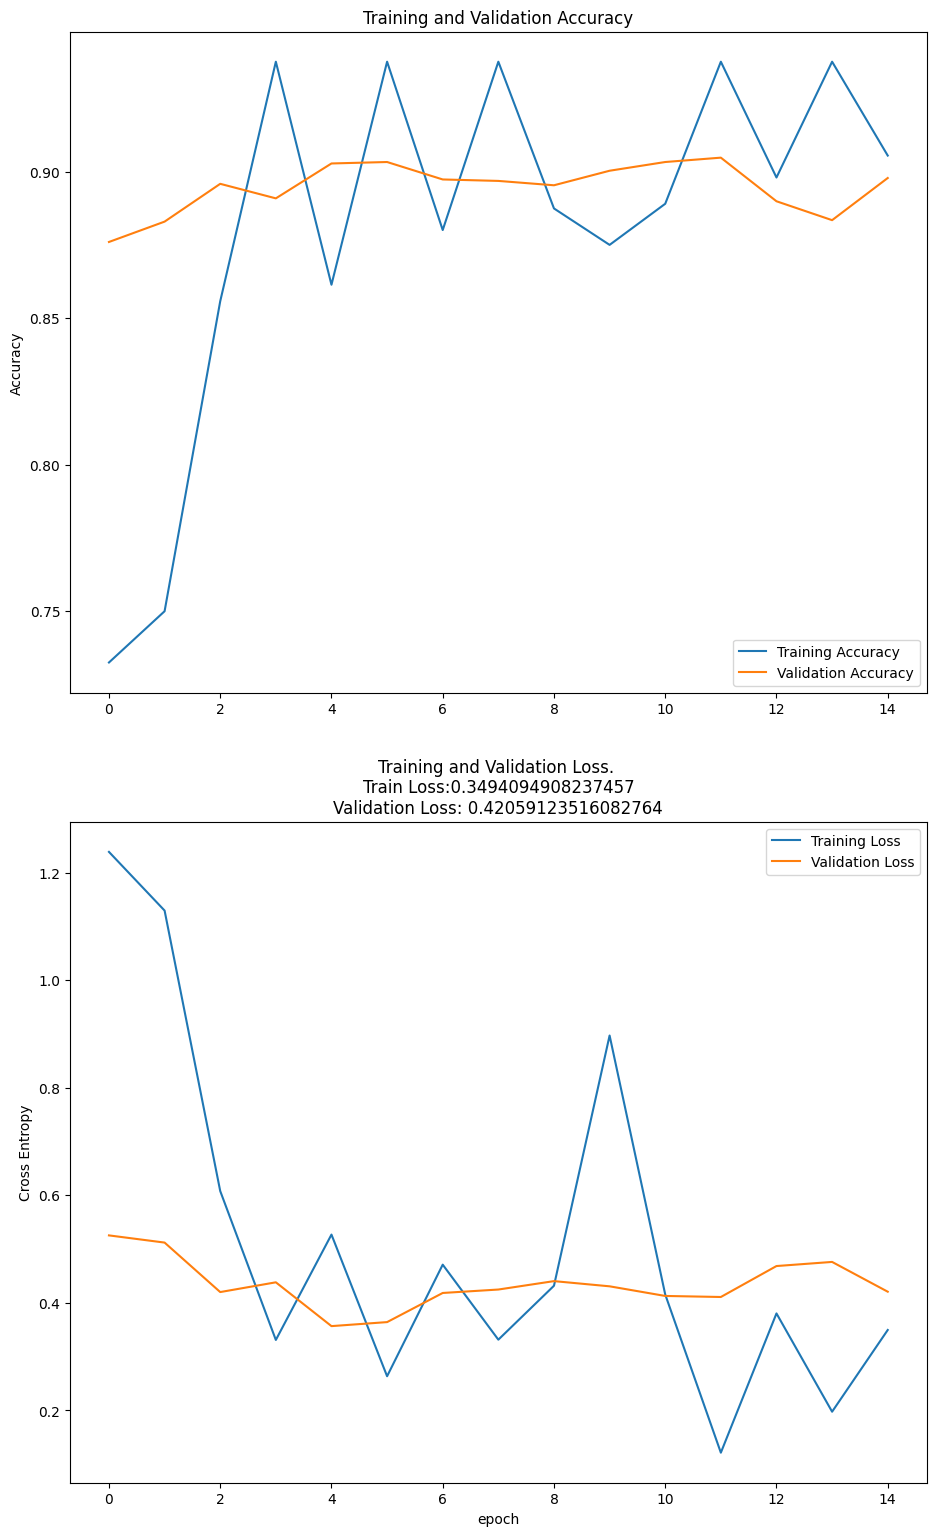

In [46]:
# 14. Visualizing the Model’s Performance
# 14a.store results
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
# history keeps track of what the model learned in each epoch.
# We save training accuracy, validation accuracy, training loss, and validation loss to see how smart the model is getting.
# 14b. Plotting Accuracy 
plt.figure(figsize=(10, 16))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.title(f'Training and Validation Accuracy')
# Draws a line graph showing how accuracy improves over time.
# Blue line (training accuracy) → how smart the computer is on pictures it practiced with.
# Orange line (validation accuracy) → how smart the computer is on new pictures it never saw.
# This graph shows how the computer gets better at guessing dog breeds over time and checks if it can do well on new pictures too
# If training accuracy is high but validation is low, the model is memorizing → overfitting.
# We can adjust things like learning rate, dropout, or early stopping based on the graph.
# 14c. Plot loss
# loss
plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
# This graph shows how wrong the model was while learning.
# Blue line (training loss) → mistakes on pictures it practiced with.
# Orange line (validation loss) → mistakes on new pictures it never saw.
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.title(f'Training and Validation Loss. \nTrain Loss:{str(loss[-1])}\nValidation Loss: {str(val_loss[-1])}')
plt.xlabel('epoch')
plt.tight_layout(pad=3.0)
plt.show()
# Labels, title, and legend → make the graph easy to understand.
# epoch → how many times the model has seen all training pictures.
# Cross Entropy → a fancy word for how wrong the guesses are.
# This graph shows how the computer makes fewer mistakes over time. If the lines go down, the model is learning well!

# Why Loss Graph Is Important
# If training loss is low but validation loss is high → model is memorizing pictures (overfitting).
# If both losses go down together → model is learning properly.
# Combined View
# Accuracy Graph → shows how often the computer is right ✅
# Loss Graph → shows how wrong the computer is ❌
# Both graphs together tell the full story of learning.

# Accuracy → shows how often the model guesses the dog breed correctly.
# Loss → shows how wrong the model’s guesses are.
# What we saw:
# Training and validation accuracy were almost the same and above 90% ✅
# → The model is learning well and not memorizing.
# Loss graph goes down steadily ⬇️
# # → The model is making fewer mistakes after each round (epoch).
# Simple way to remember:
# “The model is smart, careful, and keeps getting better!”

# “The training and validation accuracy were consistently above 90%, indicating strong learning without overfitting. The loss decreased steadily over epochs, showing the CNN model is converging and behaving as expected.”


In [47]:
# 15. Evaluating Model Accuracy
accuracy_score = model.evaluate(validation_generator)
print(accuracy_score)
print("Accuracy: {:.4f}%".format(accuracy_score[1] * 100))
print("Loss: ", accuracy_score[0])


# model.evaluate -  Checks the model on validation data (pictures it hasn’t seen while learning).
# Returns:
# Loss → how wrong the model is overall
# Accuracy → how many guesses were correct
# Printing Accuracy and Loss
# accuracy_score[1] → validation accuracy
# accuracy_score[0] → validation loss

# Think of it like a final test for the model 
# Accuracy = how many correct guesses ✅
# Loss = how many mistakes ❌
# Example output:
# Accuracy = 92% → the model is really smart
# Loss = 0.15 → it’s making very few mistakes
# “We evaluate the trained model on validation data to check performance. The evaluation returns both loss and accuracy, allowing us to confirm the model’s effectiveness on unseen data.”
# “Evaluating the model is like giving it a final exam and seeing how many answers it got right.”


64/64 ━━━━━━━━━━━━━━━━━━━━ 231s 4s/step - accuracy: 0.9049 - loss: 0.3642
[0.36658746004104614, 0.9031311273574829]
Accuracy: 90.3131%
Loss:  0.36658746004104614


<Figure size 600x600 with 0 Axes>

Text(0.5, 1.0, 'TEST IMAGE')

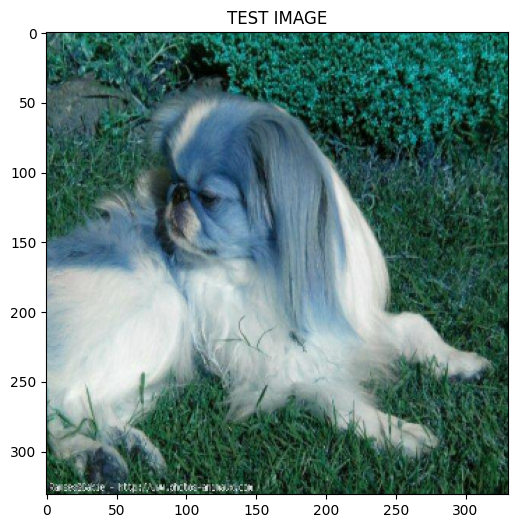

In [48]:
# 16. Viewing a Test Image
test_img_path = test_path+"/000621fb3cbb32d8935728e48679680e.jpg"

img = cv2.imread(test_img_path)
resized_img = cv2.resize(img, (331, 331)).reshape(-1, 331, 331, 3)/255

plt.figure(figsize=(6,6))
plt.title("TEST IMAGE")
plt.imshow(resized_img[0])

# Load the image
# cv2.imread → reads the picture from the folder.
# Resize the image
# cv2.resize(img, (331, 331)) → makes the picture the same size the model expects.
# Normalize the image
# Divide by 255 → turns colors into numbers between 0 and 1 (makes learning easier for the computer).
# Display the image
# plt.imshow → shows the test image.
# Title = "TEST IMAGE" → label on top of the picture.
# We take a new dog picture, make it the right size, tell the computer to understand its colors, and then show it so we can see it
# The test image is loaded, resized to the input shape of the CNN, normalized, and displayed for visualization before making predictions


In [51]:
# 17. Making predictions on the test data
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=sample,
    directory=test_path,
    x_col="id",
    y_col=None,
    target_size=(331, 331),
    batch_size=32,
    class_mode=None,
    shuffle=False
)

predictions = model.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)
# Load each test image
# load_img → reads the image.
# Convert to numbers
# img_to_array → converts picture to numbers the computer can understand.
# Resize image
# smart_resize(img, (331, 331)) → makes it the right size for the model.
# Add batch dimension
# tf.reshape(..., (-1, 331, 331, 3)) → model expects batches, even if it’s 1 image.
# Normalize
# Divide by 255 → colors become numbers between 0 and 1.
# Predict the breed
# model.predict → gives scores for all 120 breeds.
# np.argmax → picks the breed with the highest score.
# Save predictions
# Create a DataFrame with image_id and predicted label.
# Export to submission.csv


my_submission = pd.DataFrame({
    'image_id': sample.id,
    'label': predicted_labels
})

my_submission.to_csv('submission.csv', index=False)
#For each test dog picture, we teach the computer to see it, resize it, understand colors, guess the breed, and then write all guesses in a file

# Submission file output
print("Submission File: \n---------------\n")
print(my_submission.head()) # Displaying first five predicted output
# We preprocess each test image, use the trained CNN model to predict its breed, and save the predictions to a submission file


Found 10357 validated image filenames.
324/324 ━━━━━━━━━━━━━━━━━━━━ 1074s 3s/step
Submission File: 
---------------

                               image_id  label
0  000621fb3cbb32d8935728e48679680e.jpg     61
1  00102ee9d8eb90812350685311fe5890.jpg     94
2  0012a730dfa437f5f3613fb75efcd4ce.jpg     40
3  001510bc8570bbeee98c8d80c8a95ec1.jpg     88
4  001a5f3114548acdefa3d4da05474c2e.jpg     70


LabelEncoder()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


(-0.5, 330.5, 330.5, -0.5)

Text(0.5, 1.0, 'Predicted: japanese_spaniel (1.00)')

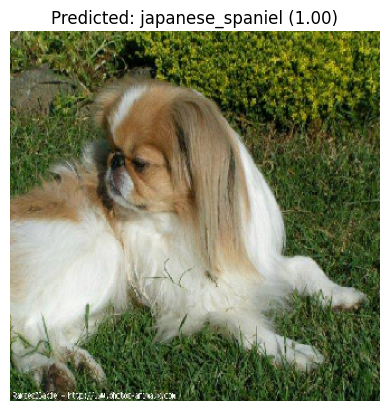

In [54]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(labels_df['breed'])

breed_labels = le.classes_


# pick one image
img_name = sample.id.iloc[0]
img_path = test_path + '/' + img_name

# load image
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(331,331))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = img_array / 255.0
img_array = tf.expand_dims(img_array, axis=0)

# predict
pred = model.predict(img_array)
pred_class = np.argmax(pred)
confidence = np.max(pred)

# show image
plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {breed_labels[pred_class]} ({confidence:.2f})")
plt.show()


<Figure size 1200x800 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'japanese_spaniel')

(-0.5, 330.5, 330.5, -0.5)

<Axes: >

...

Text(0.5, 1.0, 'lhasa')

(-0.5, 330.5, 330.5, -0.5)

<Axes: >

Text(0.5, 1.0, 'standard_poodle')

(-0.5, 330.5, 330.5, -0.5)

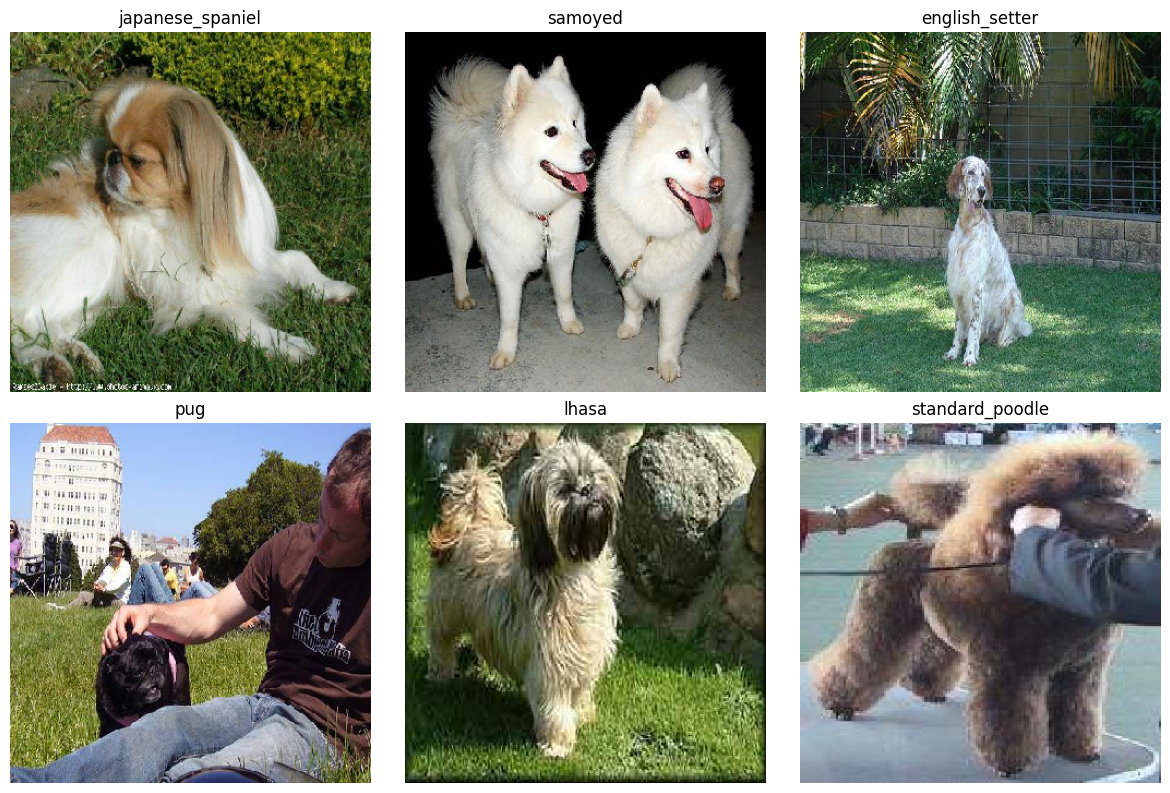

In [55]:
plt.figure(figsize=(12,8))

for i in range(6):
    img_name = sample.id.iloc[i]
    img_path = test_path + '/' + img_name

    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(331,331))
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = tf.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)
    label = breed_labels[np.argmax(pred)]

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Q1. Can you briefly describe your project?
# The project is a multiclass image classification task where we classify dog images into 120 breeds using a Convolutional Neural Network (CNN) with transfer learning. We used the pre-trained InceptionResNetV2 model, added custom dense layers, trained with data augmentation, and evaluated using accuracy, loss, and other metrics.”

# Q2. Why did you use Transfer Learning instead of training from scratch?
# “Training from scratch requires large datasets and high computational resources. Transfer learning allows us to use a pre-trained model like InceptionResNetV2, which has already learned general image features, and adapt it to our dog breed dataset. It speeds up training and improves performance, especially on limited datasets.”

# Q3. What is the size of your dataset?
# “The training dataset contains 10,222 images across 120 breeds, and the test dataset has 10,357 images. Each image is resized to 331×331 pixels for compatibility with InceptionResNetV2.”

# 2️.Data Preprocessing & Augmentation Questions
# Q4. How did you preprocess the images?
# “Images were resized to 331×331, converted to arrays, and normalized by dividing pixel values by 255. We also applied data augmentation like horizontal flips and scaling using ImageDataGenerator to increase model generalization.”

# Q5. What is the purpose of data augmentation?
# “Data augmentation helps prevent overfitting by artificially increasing dataset diversity. It allows the model to generalize better on unseen images by simulating rotations, flips, brightness changes, etc.”

# Q6. How did you split the data for training and validation?
# “We used an 80:20 split using ImageDataGenerator’s validation_split parameter, where 80% of the data is used for training and 20% for validation.”

# 3️.Model Architecture Questions
# Q7. Can you describe your model architecture?
# “We used InceptionResNetV2 as the base model (pre-trained on ImageNet) with frozen weights. On top of it, we added GlobalAveragePooling2D, BatchNormalization, three Dense layers (512, 256, 128 neurons), a Dropout layer (0.5), and a final Dense layer with 120 neurons and softmax activation.”

# Q8. Why did you use GlobalAveragePooling2D?
# “GlobalAveragePooling2D reduces the feature map into a 1D vector by averaging, which reduces the number of parameters, prevents overfitting, and prepares the features for fully connected layers.”

# Q9. What is the purpose of BatchNormalization?
# “BatchNormalization normalizes the outputs of a layer, stabilizes training, allows higher learning rates, and helps the model converge faster.”

# Q10. Why did you include Dropout?
# “Dropout randomly drops neurons during training to prevent overfitting and improve generalization.”

# Q11. What activation function did you use in the output layer and why?
# “We used softmax activation because this is a multiclass classification problem. Softmax converts logits into probabilities, and the class with the highest probability is selected as the prediction.”

# 4️. Training & Optimization Questions

# Q12. What loss function did you use and why?
# “We used categorical crossentropy because it is suitable for multiclass classification problems where each image belongs to exactly one of the 120 classes.”

# Q13. Which optimizer did you use? Why?
# “We used Adam optimizer because it combines the advantages of RMSProp and momentum, adapts learning rates for each parameter, and converges faster.”

# Q14. What is batch size, and why did you choose 32?
# “Batch size is the number of images the model sees at once during training. We chose 32 as a good balance between memory efficiency and stable gradient updates.”

# Q15. What is EarlyStopping and why did you use it?
# “EarlyStopping monitors validation loss or accuracy and stops training when no improvement is observed for a set number of epochs (patience). It prevents overfitting and saves the best model weights.”

# Q16. What is ModelCheckpoint and why is it useful?
# “ModelCheckpoint saves the model weights whenever validation performance improves. This ensures we can always recover the best-performing model even if training stops later.”

# Q17. Did you perform fine-tuning? Why?
# “Yes, after training the top layers, we unfroze the upper layers of InceptionResNetV2 and trained with a small learning rate. This helps the model learn dataset-specific features without losing pre-trained general knowledge.”

# 5️. Evaluation Questions

# Q18. How did you evaluate the model?
# “We evaluated using validation accuracy, loss, and visualized training/validation graphs. We also used metrics like confusion matrix, precision, recall, and F1-score for a deeper understanding of performance across all 120 classes.”

# Q19. What is the difference between precision and recall?
# “Precision measures how many of the predicted positives are actually correct. Recall measures how many of the actual positives the model correctly identified. F1-score balances both.”

# Q20. How did you handle multiclass evaluation metrics?
# “For multiclass evaluation, we calculated precision, recall, and F1-score for each class and used macro, micro, or weighted averages to summarize performance across all 120 classes.”

# Q21. What does a confusion matrix tell you?
# “A confusion matrix shows how many samples were correctly or incorrectly predicted for each class. It helps identify which breeds the model confuses most.”

# Q22. What is ROC and AUC, and are they useful here?
# “ROC (Receiver Operating Characteristic) and AUC (Area Under Curve) measure the model’s ability to distinguish between classes. In multiclass problems, AUC can be calculated per class or using a one-vs-rest approach to check separability.”

# 6️. Prediction & Deployment Questions

# Q23. How do you make predictions on new images?
# “We load the image, resize and normalize it, pass it through the trained model, and use np.argmax on the softmax output to pick the breed with the highest probability.”

# Q24. How did you save and load the model?
# “We used model.save('Model.h5') to save the architecture, weights, and optimizer state. Later, we can load it with load_model('Model.h5') for predictions without retraining.”

# Q25. How would you improve this model?
# “Possible improvements:
# Fine-tune more layers of the pre-trained model
# Use advanced data augmentation (rotation, zoom, brightness)
# Increase dataset size
# Experiment with other pre-trained models (EfficientNet, ResNet50)
# Apply learning rate schedulers for better convergence.”

# Q26. How do you prevent overfitting in this project?
# “We used data augmentation, dropout, EarlyStopping, and validation monitoring to prevent overfitting.”

# Q27. How would you deploy this model in production?
# “We can save the trained model (Model.h5) and deploy it using frameworks like Flask or FastAPI to build a REST API where users can upload dog images and get predicted breeds in real-time.”


In [ ]:
# Dog Breed Classification Project
# “In this project, I performed multiclass image classification to identify 120 dog breeds using a CNN with transfer learning.
# I used InceptionResNetV2 pre-trained on ImageNet as the base model. I froze the base initially to retain the learned general image features like edges, shapes, and textures. On top, I added GlobalAveragePooling2D, BatchNormalization, Dense layers (512, 256, 128), a Dropout layer (0.5), and a final Dense layer with softmax for 120 classes.
# Images were resized to 331×331 and normalized to [0,1]. I applied data augmentation like horizontal flips to increase data diversity, helping the model generalize better.
# For training, I used Adam optimizer for faster convergence, categorical crossentropy as the loss function for multiclass classification, and a batch size of 32 for memory efficiency and stable gradient updates. I trained the model for 25 epochs with EarlyStopping to prevent overfitting and restore the best weights. I also visualized training and validation accuracy and loss over epochs.
# The model achieved over 90% training and validation accuracy, with loss steadily decreasing, indicating proper learning without overfitting. For evaluation, I used accuracy, loss, confusion matrix, precision, recall, and F1-score to measure performance for each class.
# Finally, the trained model was saved as Model.h5, and predictions were made on test images by resizing, normalizing, and passing through the model. The class with the highest probability was selected as the predicted breed.
# Overall, careful choices in model architecture, optimizer, batch size, data augmentation, and early stopping helped achieve high performance while preventing overfitting.”

# Why choices were made:
# Pre-trained model → reuse general features
# Data augmentation → prevent overfitting
# Adam optimizer → fast, adaptive learning
# Batch size → memory and stable learning
# Overfitting prevention: Dropout, EarlyStopping, data augmentation, validation monitoring
# Evaluation metrics: Accuracy, loss, confusion matrix, precision, recall, F1-score
# Numbers to impress:
# Training & validation accuracy > 90%
# Loss decreases steadily over epochs


In [ ]:
# 1. Transfer Learning & Pre-trained Models
# Q1. Why did you freeze the base model initially, and when would you unfreeze it?
# “Freezing the base model prevents the pre-trained weights from being updated during initial training. This preserves the general features learned on ImageNet. Once the top layers are trained, we can unfreeze some of the upper layers for fine-tuning, allowing the model to adapt to dataset-specific features like dog breeds, while keeping the lower-level features stable.”
# Q2. Why choose InceptionResNetV2 over other pre-trained models like ResNet50 or EfficientNet?
# “InceptionResNetV2 combines Inception modules with residual connections, allowing very deep networks (164 layers) to train efficiently. It captures multi-scale features while maintaining convergence stability. EfficientNet is more parameter-efficient, but for our dataset size and input resolution (331×331), InceptionResNetV2 provides strong feature extraction out-of-the-box.”
# Q3. How do you decide which layers to freeze or unfreeze?
# “We usually freeze all convolutional layers initially and train the top Dense layers. For fine-tuning, we unfreeze the upper layers near the output because they capture higher-level features that are more dataset-specific. Lower layers are kept frozen as they represent generic features like edges and textures.”

# 2️. Data Augmentation & Preprocessing
# Q4. Can you explain the difference between real-time augmentation and offline augmentation?
# “Real-time augmentation (like ImageDataGenerator) generates transformed images on-the-fly during training, saving memory and providing infinite variability. Offline augmentation generates and stores augmented images beforehand, increasing storage requirements but sometimes reducing CPU/GPU overhead during training.”
# Q5. How would you handle class imbalance in a multiclass dataset?
# “Options include:
# Class weighting in the loss function to penalize minority classes more.
# Oversampling minority classes using augmentation.
# Undersampling majority classes carefully to prevent overfitting.
# For our dog dataset, class weighting with class_weight in Keras is efficient.”

# 3️. Model Architecture & Layers
# Q6. Why did you use GlobalAveragePooling2D instead of Flatten?
# “GlobalAveragePooling2D reduces each feature map to a single value by averaging, drastically reducing parameters compared to Flatten. This reduces overfitting, keeps spatial information summary, and speeds up training. Flatten would create a huge vector (~9×9×1536), increasing computation and overfitting risk.”
# Q7. How does BatchNormalization help in convergence?
# “BatchNormalization normalizes activations per batch, reducing internal covariate shift, allowing the model to use higher learning rates, converge faster, and improve generalization.”
# Q8. How do Dropout and BatchNormalization interact?
# “BatchNormalization stabilizes activations, and Dropout randomly deactivates neurons. Typically, Dropout is applied after BatchNormalization, as BN reduces internal variance, and Dropout further prevents overfitting.”
# Q9. Why did you use softmax instead of sigmoid in the output layer?
# “Softmax converts logits into a probability distribution across 120 classes. Sigmoid is for multi-label classification (multiple classes per image), whereas softmax is for single-class, multiclass problems.”

# 4️. Training & Optimization
# Q10. Why did you choose Adam over SGD?
# “Adam adapts learning rates per parameter using momentum and moving averages, converging faster. SGD requires careful tuning of learning rates and momentum. Adam is particularly useful for deep networks and heterogeneous data.”
# Q11. How do you decide the learning rate for fine-tuning?
# “Fine-tuning requires a small learning rate (e.g., 1e-4 or 1e-5) to prevent large weight updates that could destroy pre-trained features. During top-layer training, a higher learning rate (1e-3) is acceptable.”
# Q12. What would you do if your model overfits despite using Dropout and EarlyStopping?
# “Options include:
# Increase data augmentation (rotation, zoom, brightness, horizontal/vertical flips).
# Reduce network complexity (fewer dense neurons).
# Use L2 weight regularization.
# Implement learning rate scheduling.
# Consider more training data if possible.”

# 5️. Evaluation & Metrics
# Q13. Why use categorical crossentropy as the loss function?
# # Categorical crossentropy measures the difference between predicted probability distribution and true one-hot encoded labels for multiclass problems. It penalizes incorrect predictions proportionally to how wrong the probability distribution is.”
# Q14. How do you evaluate performance in multiclass classification?
# “We use:
# Accuracy for overall performance.
# Confusion matrix to see class-wise errors.
# Precision, Recall, F1-score per class.
# Macro/micro/weighted averages for overall metrics.
# For our model, training and validation accuracy exceeded 90%, and loss steadily decreased, showing good generalization.”
# Q15. How would you interpret a high training accuracy but low validation accuracy?
# “This indicates overfitting — the model memorized training images but cannot generalize to unseen data. Solutions include increasing augmentation, using more dropout, early stopping, or regularization.”
# Q16. How do ROC and AUC work in multiclass problems?
# “ROC curves are usually one-vs-rest for each class. AUC measures the area under each ROC curve, indicating how well the model separates a class from the rest. Macro-average or weighted AUC summarizes overall performance.”

# 6️. Deployment & Prediction
# Q17. How do you handle preprocessing in production for new images?
# “New images must be resized to 331×331, normalized (divide by 255), and optionally batch dimension added before prediction. The preprocessing pipeline must be consistent with training.”
# Q18. How would you deploy this model for real-time inference?
# “I would use Flask or FastAPI to build a REST API. Images are sent via POST requests, preprocessed, and passed through the trained model. Predicted breed is returned as JSON. GPU inference or TensorRT can accelerate predictions.”
# Q19. How would you handle very similar dog breeds that the model confuses?
# “Options:
# Use higher resolution images for more detailed features.
# Fine-tune deeper layers to capture subtle differences.
# Use attention mechanisms or Siamese networks for feature comparison.
# Add additional metadata like dog size or color if available.”
# Q20. How scalable is your solution for thousands of classes?
# for more classes:
# Use efficient pre-trained models like EfficientNet.
# Increase dataset size and augmentation.
# Use label encoding or embeddings for output layers.
# Consider hierarchical classification to first group breeds, then fine-classify.
